In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data

In [5]:
# number of jobs
cluster_size = 100

# number of rounds
rounds_list = range(2,12,2)

# Save logical error
Logical_Error = np.full(len(rounds_list),np.nan)
# Save logical error uncertainty
Logical_Error_u = np.full(len(rounds_list),np.nan)

# loop through number of rounds
for index_rounds, rounds in enumerate(rounds_list): 
    nb_accepted = 0
    nb_fail = 0
    for index in range(cluster_size):
        result = json.load(open(f'./Results/result_{rounds}_{index}.json', 'r'))

        nb_fail += result['accepted&fail']
        nb_accepted += result['accepted']

    if nb_accepted != 0:
        Logical_Error[index_rounds] = nb_fail/nb_accepted
        Logical_Error_u[index_rounds] = 1.96*np.sqrt(nb_fail/nb_accepted**2)

# Logical error

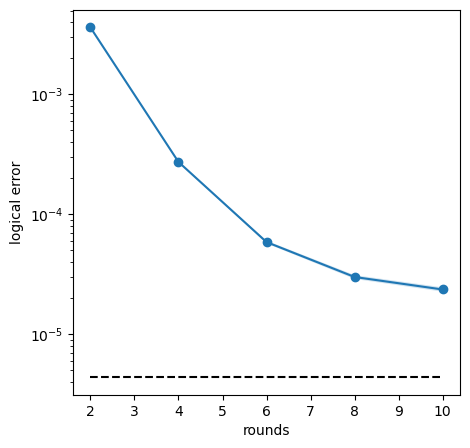

In [7]:
plt.figure(figsize=(5, 5))     
      
# logical error
plt.plot(np.array(rounds_list),Logical_Error,'-o')
# error bar
plt.fill_between(np.array(rounds_list),Logical_Error - Logical_Error_u,
                 Logical_Error + Logical_Error_u, alpha=0.2)

# theoritcal 35p^3 of distillation
plt.plot([rounds_list[0],rounds_list[-1]],[35*(0.005*2/3+0.005/3)**3,35*(0.005*2/3+0.005/3)**3],'--',c='k')

plt.yscale('log')

plt.xlabel('rounds')
plt.ylabel('logical error')
plt.show()

In [8]:
column_names = [f"{i} rounds" for i in range(2,12,2)]
index_names = ['Logical error']
df = pd.DataFrame(Logical_Error.reshape(1, -1), columns=column_names, index = index_names)
pd.set_option('display.float_format', '{:.2e}'.format)
df

,2 rounds,4 rounds,6 rounds,8 rounds,10 rounds
Logical error,3.62e-03,2.73e-04,5.86e-05,3.00e-05,2.36e-05
